In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
### ERREUR DINDICAGE

def worst_convex(x,t,T):
    term_1 = np.sum(((7/8)*x[::T]- x[1::T])**2)

    indices = np.arange(1,T*t+1)
    mask_neg = (indices % T != 0)     
    mask_pos = (indices % T != 1)   
    neg = x[mask_neg]
    pos = x[mask_pos]
    pos[0] = 0
    term_2 = np.sum((pos-neg)**2)
    return 0.5*(term_1 + term_2)

def grad_worst_convex(x, t, T):

    n = T * t
    assert x.shape[0] == n
    g = np.zeros_like(x)


    i0 = np.arange(T-1, n-1, T)   # indices de x[::T]
    i1 = np.arange(0, n, T)   # indices de x[1::T]

    # e = (7/8)*x[i0] - x[i1]   # erreurs

    # d/dx 0.5 * term_1
    # pour i0 : (7/8) * e
    # pour i1 : - e
    # print(g[np.where(g!=0)])
    g[i0] += (7/8) *( (7/8)*x[i0] - x[i1][1::])
    # print(g[np.where(g!=0)])
    g[i1] += - ((7/8)*np.concatenate(([0],x[i0])) - x[i1] )
    ########"g[g<10**(-12)] = 0
    # i0 = np.arange(0, n, T)   # indices de x[::T]
    # i1 = np.arange(1, n, T)   # indices de x[1::T]

    # e = (7/8)*x[i0] - x[i1]   # erreurs
    # # e[0] = -x[i1][0]
    # # d/dx 0.5 * term_1
    # # pour i0 : (7/8) * e
    # # pour i1 : - e
    # g[i0] += (7/8) * e
    # g[i1] += -e
    # print(g[np.where(g!=0)])
    # ----- Gradient de term_2 -----
    # term_2 = sum_j (pos_j - neg_j)^2
    indices = np.arange(1, n + 1)
    mask_neg = (indices % T != 0)
    mask_pos = (indices % T != 1)

    idx_neg = np.nonzero(mask_neg)[0]   # indices originaux dans x pour neg
    idx_pos = np.nonzero(mask_pos)[0]   # indices originaux dans x pour pos

    neg = x[idx_neg]
    pos = x[idx_pos]
    d = pos - neg                        # pos - neg

    # d/dx 0.5 * term_2 :
    # d/d pos = (pos - neg) = d
    # d/d neg = -(pos - neg) = -d
    g[idx_pos] += d
    g[idx_neg] -= d
    # g[g<10**(-12)] = 0

    # print(g[np.where(g!=0)][:50])
    return g

def g(x,t,T,y):
    return worst_convex(x,t,T) + v(x,y)

def grad_g(x,t,T,y):
    return grad_worst_convex(x,t,T) + deriv_v(x,y)

def v(x,y):
    vec_1 = (x <= (31/32)*y)*0.5*x**2 
    vec_2 =  ((31/32)*y < x)*(x <= y)*(0.5*x**2-16*(x-(31/32)*y)**2)
    vec_3 = (y < x)*(x <= (33/32)*y) * (0.5*x**2 - (1/32)*y**2 + 16*(x-(33/32)*y)**2)
    vec_4 = (x > (33/32)*y)*(0.5*x**2 -  (1/32)*y**2)
    return np.sum(vec_1 + vec_2 + vec_3 + vec_4)

def b(x,y):
    return ((31/32)*y <= x)*(x <= (33/32)*y)*(y-32*np.abs(x-y))
def deriv_v(x,y):
    deriv = x-b(x,y)
    deriv[deriv < 10**(-8)] = 0
    return deriv

def norm(x):
    return np.sqrt(np.sum(x**2))

# def g_tilde(x,t,T,D,L,y):
#     return (1/37)*L*T**(-1)*D**2*g(y-np.sqrt(T)*D**(-1)*x,t,T,y)

# def grad_g_tilde(x,t,T,D,L,y):
#     return -(1/37)*L*T**(-0.5)*D*grad_g(y-np.sqrt(T)*D**(-1)*x,t,T,y)

def g_tilde(x,t,T,D,L,y):
    return (1/37)*L*g(y-x,t,T,y)

def grad_g_tilde(x,t,T,D,L,y):
    return -(1/37)*L*grad_g(y-x,t,T,y)


True
13
2275.0


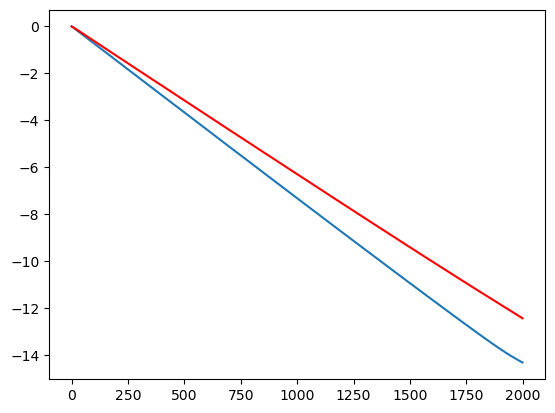

In [34]:
mu = 1*10**-4
L = 10**3
epsilon = 10**(-10)
kappa = L/mu
C3 = 21344400/1083
C4 = 370*C3
print(kappa>C4)
T = int(np.floor(kappa/(37*C3)))
t = int(2*np.floor(np.log(3/(2*epsilon))/np.log(8/7)))
n = T*t
print(T)
D = 20
y = (7/8)**(np.repeat(np.arange(0, t), T))
x_ast = y*D*T**(-1/2)
x_ast = y
x = np.zeros(n)


n_iter = 2000
corr = np.empty(n_iter)
corr_nag = np.empty(n_iter)
f_alg = np.empty(n_iter)
f_nag = np.empty(n_iter)
x_alg = np.zeros(n)
x_nag = np.zeros(n)
x_nag_prec = np.zeros(n)
y_nag = np.zeros(n)
f_alg[0] = g_tilde(np.zeros(n),t,T,D,L,y)
f_nag[0] = g_tilde(np.zeros(n),t,T,D,L,y)
corr[0] = np.sum(grad_g_tilde(x_alg,t,T,D,L,y)*(x_alg-x_ast))/(norm(grad_g_tilde(x_alg,t,T,D,L,y))*norm(x_alg-x_ast))
corr_nag[0] = np.sum(grad_g_tilde(x_alg,t,T,D,L,y)*(x_alg-x_ast))/(norm(grad_g_tilde(x_alg,t,T,D,L,y))*norm(x_alg-x_ast))
#D = norm(x)
alpha =0.5
mu = np.zeros(n_iter)
for i in range(1,n_iter):
    grad =  grad_g_tilde(x_alg,t,T,D,L,y)
    mu[i] = 0.5*norm(grad**2)/(g_tilde(x_alg,t,T,D,L,y))
    # print(0.5*norm(grad**2)/(g_tilde(x_alg,t,T,D,L,y)))


    corr[i] = np.sum(grad*(x_alg-x_ast))/(norm(grad)*norm(x_alg-x_ast))
    y_nag = x_nag + alpha*(x_nag-x_nag_prec)
    x_nag_prec = x_nag

    grad_nag = grad_g_tilde(y_nag,t,T,D,L,y)
    x_nag = y_nag - grad_nag*L**(-1)*5
    corr_nag[i] = np.sum(grad_nag*(y_nag-x_ast))/(norm(grad_nag)*norm(y_nag-x_ast))
    # print("corr :", corr[i])
    # print(sum(grad*(x_alg-x_ast))/g_tilde(x_alg,t,T,D,L,y))
    x_alg -= grad*L**(-1)*13
    f_alg[i] = g_tilde(x_alg,t,T,D,L,y)
    f_nag[i] = g_tilde(x_nag,t,T,D,L,y)
    # mu = min(0.5*norm(grad_g(y-x_alg,t,T,y))**2/(g(y-x_alg,t,T,y)),mu)
    
print(T*t/2)
plt.plot(np.log(f_alg/f_alg[0])/np.log(10))
plt.plot(np.log(f_nag/f_nag[0])/np.log(10),c="r")


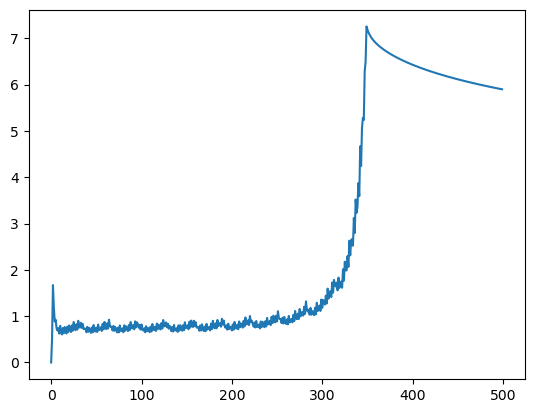

In [14]:
grad_g_tilde(np.zeros(n),t,T,D,L,y)
plt.plot(mu)

In [125]:
T*t/2

2275.0

In [162]:
L_0 = g_tilde(np.zeros(n),t,T,D,L,y)/norm(x_ast)**2
L_0

13.351091476091478

array([0.13427154, 0.13427154, 0.12907238, ..., 0.13120716, 0.12607593,
       0.12706781])

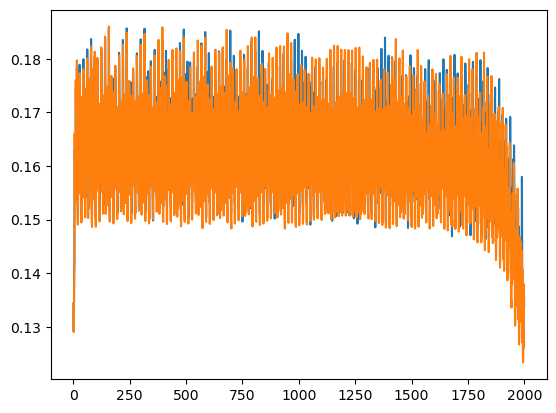

In [30]:
plt.plot(corr)
plt.plot(corr_nag)
corr
corr_nag

In [4]:
mu = 1*10**-5
L = 2*10**6
epsilon = 10**(-10)
kappa = L/mu
C3 = 21344400/1083
C4 = 370*C3
T = int(np.floor(kappa/(37*C3)))
t = int(2*np.floor(np.log(3/(2*epsilon))/np.log(8/7)))
n = T*t
print(T)
D = 20
y = (7/8)**(np.repeat(np.arange(0, t), T))
x_ast = y*D*T**(-1/2)
x_ast = y
x = np.zeros(n)


x_alg = np.zeros(n)
grad = grad_g_tilde(x_alg,t,T,D,L,y)
corr= np.sum(grad*(x_alg-x_ast))/(norm(grad)*norm(x_alg-x_ast))
print(grad[0],corr)

274266
-54054.05405405406 0.0009244206880747593


In [99]:

L_0 = g_tilde(np.zeros(n),t,T,D,L,y)/norm(x_ast)**2

In [101]:
L/np.sqrt(mu)

788341690.5502007

In [6]:
import numpy as np

def worst_function_nesterov(x, L=1.0):
    """
    Nesterov's 'worst function in the world'
    f(x) = 1/2 (x1 - 1)^2 + 1/2 sum_{i=1}^{d-1} (x_i - x_{i+1})^2,
    éventuellement multipliée par L/4 pour avoir un gradient L-Lipschitz.

    Paramètres
    ----------
    x : array_like, shape (d,)
        Point où évaluer la fonction.
    L : float, optional
        Constante de Lipschitz souhaitée pour le gradient.
        La version de base (L=1) a grad-Lipschitz ≈ 4, donc on met un facteur L/4.

    Retour
    ------
    float
        Valeur de f(x).
    """
    x = np.asarray(x, dtype=float)
    d = x.size

    # Version "unscaled" de Nesterov
    term1 = 0.5 * (x[0] - 1.0)**2
    term2 = 0.5 * np.sum((x[:-1] - x[1:])**2)

    f_unscaled = term1 + term2

    # On la scale pour avoir un gradient L-Lipschitz
    return (L / 4.0) * f_unscaled


def grad_worst_function_nesterov(x, L=1.0):
    """
    Gradient de la 'worst function in the world' de Nesterov.

    ∇f(x)_1   = (x1 - 1) + (x1 - x2)
    ∇f(x)_j   = (x_j - x_{j-1}) + (x_j - x_{j+1})   pour 1 < j < d
    ∇f(x)_d   = (x_d - x_{d-1})

    Puis on multiplie tout par L/4 (comme pour la fonction).
    """
    x = np.asarray(x, dtype=float)
    d = x.size

    g = np.zeros_like(x)

    if d == 1:
        # Cas trivial 1D : f(x) = 1/2 (x-1)^2
        g[0] = (x[0] - 1.0)
        return (L / 4.0) * g

    # j = 1 (index 0)
    g[0] = (x[0] - 1.0) + (x[0] - x[1])

    # 1 < j < d
    if d > 2:
        g[1:-1] = (x[1:-1] - x[:-2]) + (x[1:-1] - x[2:])

    # j = d (dernier)
    g[-1] = (x[-1] - x[-2])

    return (L / 4.0) * g


In [80]:
d = 14000000
x = np.zeros(d)

f = worst_function_nesterov(x, L=1.0)
g = grad_worst_function_nesterov(x, L=1.0)

print("f(x) =", f)
print("||grad f(x)|| =", np.linalg.norm(g))
np.sum(g*(x-np.ones(d)))/(norm(g)*norm(np.ones(d)))

f(x) = 0.125
||grad f(x)|| = 0.25


0.0002672612419124244

In [53]:
d = 10**3
x = np.zeros(d)
n_iter = 10**4
f = np.empty(n_iter)
f[0] = worst_function_nesterov(x, L=1.0)
for i in range(1,n_iter):
    g = grad_worst_function_nesterov(x, L=1.0)
    # print(np.sum(g*(x-np.ones(d)))/(norm(g)*norm(np.ones(d))))
    print(np.sum(g*(x-np.ones(d)))/worst_function_nesterov(x, L=1.0))
    x -= g
    f[i] = worst_function_nesterov(x, L=1.0)
    # print(x[:10])

2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
1.9999999999999998
2.0000000000000004
2.0
1.9999999999999998
2.0
2.0
2.0
2.0000000000000004
2.0000000000000004
1.9999999999999993
1.9999999999999996
2.0
2.0
1.9999999999999996
1.9999999999999996
1.9999999999999996
1.9999999999999996
2.0
2.0
2.0
2.0000000000000004
2.0
1.9999999999999996
2.0
1.9999999999999998
2.0
2.0000000000000004
2.0
2.0000000000000004
2.0
2.0
2.0
2.0
1.9999999999999998
1.9999999999999998
1.9999999999999998
1.9999999999999998
2.0
1.9999999999999998
2.0
2.0
2.0000000000000004
1.9999999999999998
2.0
1.9999999999999998
1.9999999999999998
2.0
2.0000000000000004
1.9999999999999998
2.0
2.0
1.9999999999999998
2.0
2.0
2.0000000000000004
2.0
2.0000000000000004
1.9999999999999998
2.0000000000000004
2.0
2.0
2.0
1.9999999999999998
2.0
2.0
2.0
1.9999999999999998
2.0
2.0
2.0
2.0
2.0000000000000004
2.0
1.9999999999999998
2.0
2.0
2.0
2.0
1.9999999999999996
2.0
2.0000000000000004
2.0
2.0
1.9999999999999996
1.999999999

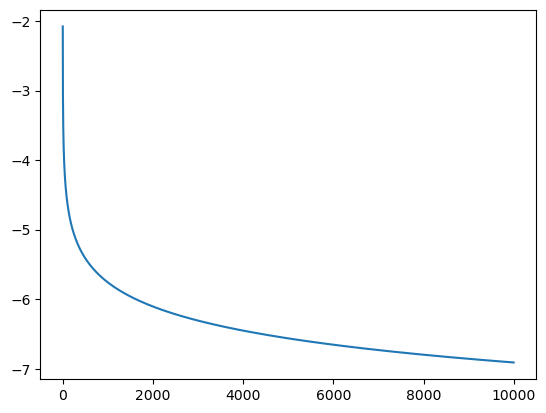

In [40]:
plt.plot(np.log(f))

In [41]:
x

array([9.88716349e-01, 9.77434955e-01, 9.66158073e-01, 9.54887954e-01,
       9.43626849e-01, 9.32376998e-01, 9.21140639e-01, 9.09920001e-01,
       8.98717301e-01, 8.87534747e-01, 8.76374537e-01, 8.65238852e-01,
       8.54129860e-01, 8.43049714e-01, 8.32000550e-01, 8.20984483e-01,
       8.10003611e-01, 7.99060011e-01, 7.88155737e-01, 7.77292821e-01,
       7.66473270e-01, 7.55699066e-01, 7.44972164e-01, 7.34294492e-01,
       7.23667951e-01, 7.13094410e-01, 7.02575708e-01, 6.92113655e-01,
       6.81710026e-01, 6.71366563e-01, 6.61084975e-01, 6.50866937e-01,
       6.40714085e-01, 6.30628021e-01, 6.20610310e-01, 6.10662479e-01,
       6.00786015e-01, 5.90982368e-01, 5.81252946e-01, 5.71599119e-01,
       5.62022215e-01, 5.52523521e-01, 5.43104282e-01, 5.33765702e-01,
       5.24508941e-01, 5.15335118e-01, 5.06245307e-01, 4.97240541e-01,
       4.88321808e-01, 4.79490053e-01, 4.70746175e-01, 4.62091033e-01,
       4.53525438e-01, 4.45050160e-01, 4.36665923e-01, 4.28373408e-01,
      

In [35]:
np.sum(grad_g_tilde(x_alg,t,T,D,L,y)*(x_alg-x_ast))/(norm(grad_g_tilde(x_alg,t,T,D,L,y))*norm(x_alg-x_ast))

0.1342715388823937

In [750]:
x_alg = np.zeros(n)
grad = grad_g_tilde(x_alg,t,T,D,L,y)
np.sum(grad*(x_alg-x_ast))/(norm(grad)*norm(x_alg-x_ast))

np.float64(0.09316949906249124)

In [248]:
t*T/2

23975.0

In [293]:
test_zero = np.zeros(n)
bound=50
test_zero[0:bound]=1
grad_worst_convex(y-test_zero,t,T)[0:50]



array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.])

In [222]:
test_zero = np.zeros(n)
test_zero[0]=1
test_zero[1]=1
test_zero[2]=1
grad_g(y-test_zero,t,T,y)[:10]

array([ 0.,  0., -1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.])

In [317]:
T

137

In [348]:
len(np.where(grad_g_tilde(x_alg,t,T,D,L,y)!=0)[0])
grad_g_tilde(x_alg,t,T,D,L,y)[T]
grad_worst_convex(y-test_zero)

TypeError: grad_worst_convex() missing 2 required positional arguments: 't' and 'T'

np.float64(-0.0)

In [329]:
# np.where(grad_g(y-np.sqrt(T)*D**(-1)*x_alg,t,T,y)!=0)[0]
np.where(grad_worst_convex(y-np.sqrt(T)*D**(-1)*x_alg,t,T)!=0)[0]
np.where(deriv_v(y-np.sqrt(T)*D**(-1)*x_alg,y)!=0)[0]
np.where(x_alg !=0)

(array([], dtype=int64),)

In [469]:
def worst_convex(x,t,T):
    term_1 = np.sum(((7/8)*x[::T]- x[1::T])**2)

    indices = np.arange(1,T*t+1)
    mask_neg = (indices % T != -1)     
    mask_pos = (indices % T != 0)   
    neg = x[mask_neg]
    pos = x[mask_pos]
    term_2 = np.sum((pos-neg)**2)
    return 0.5*(term_1 + term_2)

def grad_worst_convex(x, t, T):

    n = T * t
    assert x.shape[0] == n
    g = np.zeros_like(x)


    i0 = np.arange(T-1, n-1, T)   # indices de x[::T]
    i1 = np.arange(0, n, T)   # indices de x[1::T]

    # e = (7/8)*np.concatenate(([0],x[i0])) - x[i1]   # erreurs
    # print(i1)
    # d/dx 0.5 * term_1
    # pour i0 : (7/8) * e
    # pour i1 : - e
    print(i0[:6],i1[:6])
    g[i0] += (7/8) *( (7/8)*x[i0] - x[i1][1::])
    print(x[i0][:6])
    print(x[i1][:6])
    print(np.where(g!=0))
    # g[i1] += - (7/8)*np.concatenate(([0],x[i0])) - x[i1] 
    # print(np.where(g!=0))
    # ----- Gradient de term_2 -----
    # term_2 = sum_j (pos_j - neg_j)^2
    # indices = np.arange(1, n + 1)
    # mask_neg = (indices % T != 0)
    # mask_pos = (indices % T != 1)

    # idx_neg = np.nonzero(mask_neg)[0]   # indices originaux dans x pour neg
    # idx_pos = np.nonzero(mask_pos)[0]   # indices originaux dans x pour pos

    # neg = x[idx_neg]
    # pos = x[idx_pos]
    # d = pos - neg                        # pos - neg

    # # d/dx 0.5 * term_2 :
    # # d/d pos = (pos - neg) = d
    # # d/d neg = -(pos - neg) = -d
    # g[idx_pos] += d
    # g[idx_neg] -= d

    return g

In [470]:
np.where(grad_worst_convex(y,t,T)!= 0)[-0]


[136 273 410 547 684 821] [  0 137 274 411 548 685]
[1.         0.875      0.765625   0.66992188 0.58618164 0.51290894]
[1.         0.875      0.765625   0.66992188 0.58618164 0.51290894]
(array([ 2876,  3150,  4109,  4520,  5616,  5753,  6438,  6712,  7123,
        7534,  7671,  8767,  8904,  9041,  9726, 10000, 10137, 10274,
       10411, 10548, 10685, 11233, 11370, 11507, 11781, 12192, 13425,
       13562, 13699, 13836, 13973, 14110, 14247, 14932, 15069, 15206,
       15754, 19590, 20960, 21371, 22056, 22193, 22878, 23152, 23974,
       26440, 26714, 27399, 27536, 27810, 27947, 28084, 28221, 28358,
       28632, 29317, 30824, 31372, 31509, 31783, 31920, 32057, 34934,
       35071, 36167, 36304, 36989, 37948, 38222, 39729, 40551, 41373,
       42058, 42743, 43839, 44113, 45209, 45346, 45483, 46305, 46579,
       46716, 46990, 47264]),)


array([ 2876,  3150,  4109,  4520,  5616,  5753,  6438,  6712,  7123,
        7534,  7671,  8767,  8904,  9041,  9726, 10000, 10137, 10274,
       10411, 10548, 10685, 11233, 11370, 11507, 11781, 12192, 13425,
       13562, 13699, 13836, 13973, 14110, 14247, 14932, 15069, 15206,
       15754, 19590, 20960, 21371, 22056, 22193, 22878, 23152, 23974,
       26440, 26714, 27399, 27536, 27810, 27947, 28084, 28221, 28358,
       28632, 29317, 30824, 31372, 31509, 31783, 31920, 32057, 34934,
       35071, 36167, 36304, 36989, 37948, 38222, 39729, 40551, 41373,
       42058, 42743, 43839, 44113, 45209, 45346, 45483, 46305, 46579,
       46716, 46990, 47264])

In [441]:
n-T

47813

In [570]:


n = T * t
base = np.longdouble(7) / np.longdouble(8)
y = base ** np.longdouble(np.repeat(np.arange(0, t), T))
# y = (7/8)**(np.repeat(np.arange(0, t), T))
assert y.shape[0] == n
g = np.zeros_like(y)

print(y.dtype)
i0 = np.arange(T-1, n-1, T)   # indices de x[::T]
i1 = np.arange(0, n, T)   # indices de x[1::T]
g[i0] += (7/8) *( (7/8)*y[i0] - y[i1][1::])
print(g[:50])
# i1 = np.arange(0, n, T)   # indices de x[1::T]

# e = (7/8)*np.concatenate(([0],x[i0])) - x[i1]   # erreurs
# print(i1)
# d/dx 0.5 * term_1
# pour i0 : (7/8) * e
# pour i1 : - e

# (7/8)*y[i0][20]-y[i1][21]
np.where(g!=0)
print(g[np.where(g!=0)])

float64
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -6.07153217e-18  0.00000000e+00  0.00000000e+00
  0.00000000e+00  6.07153217e-18  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
[-6.07153217e-18  6.07153217e-18  3.03576608e-18  1.51788304e-18
  7.58941521e-19 -3.79470760e-19 -1.89735380e-19  1.89735380e-19
 -9.48676901e-20 -9.48676901e-20  9.48676901e-20

In [567]:
base = mp.mpf('7')/mp.mpf('8')
y = [base ** k for k in np.repeat(np.arange(0, t), T)]

In [577]:
for i in range(1,1000,10):
    print((7/8)**i-(7/8)*(7/8)**(i-1))

0.0
0.0
6.938893903907228e-18
0.0
-8.673617379884035e-19
0.0
0.0
1.3552527156068805e-20
0.0
0.0
2.117582368135751e-22
5.293955920339377e-23
0.0
0.0
0.0
0.0
-5.169878828456423e-26
0.0
0.0
0.0
-4.0389678347315804e-28
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.2037062152420224e-35
3.009265538105056e-36
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.1479437019748901e-41
0.0
0.0
0.0
0.0
2.2420775429197073e-44
0.0
0.0
0.0
0.0
0.0
5.473822126268817e-48
0.0
3.4211388289180104e-49
-8.552847072295026e-50
0.0
0.0
0.0
-6.681911775230489e-52
0.0
0.0
0.0
0.0
-6.525304467998525e-55
1.6313261169996311e-55
4.078315292499078e-56
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
7.778769097326427e-62
-1.9446922743316068e-62
0.0
0.0
0.0
7.596454196607839e-65
-1.8991135491519597e-65
0.0
2.3738919364399497e-66
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [578]:
(7/8)**1000

1.0187157538264446e-58